## Task B1

In [1]:
# Grayscale img Converter
import cv2

image = cv2.imread('imgs/maxresdefault.jpg')

grayscale_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

cv2.imwrite('hell_cute_cat.jpg', grayscale_image)
# cv2.imshow('hell_cute_cat.jpg',grayscale_image)

True

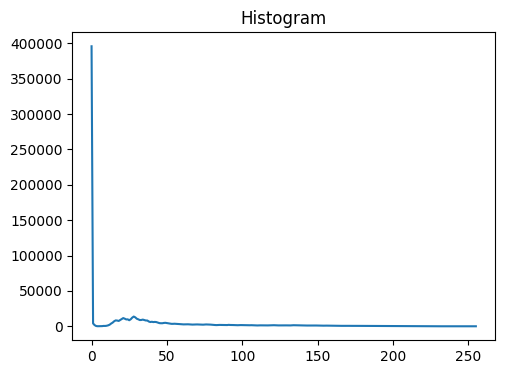

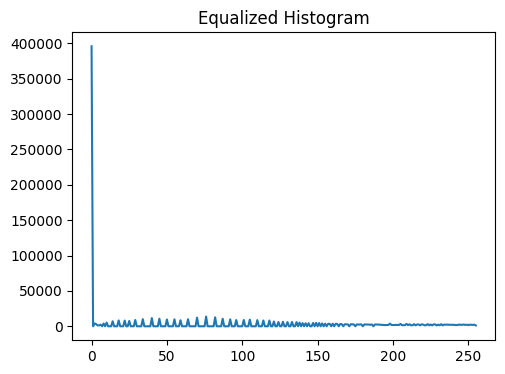

In [2]:
# a, Histogram and histogram equalization:
# - Compute and display the histogram of the grayscale image.
# - Apply histogram equalization to the grayscale image.
# - Compute and display the histogram of the equalized image.

import cv2 
import numpy as np
import matplotlib.pyplot as plt

I_og = cv2.imread('imgs/maxresdefault.jpg')
I = cv2.imread('imgs/hell_cute_cat.jpg',cv2.IMREAD_GRAYSCALE)

hist = cv2.calcHist([I], [0], None, [256], [0, 256])


I_equalized = cv2.equalizeHist(I)
cv2.imwrite('equalized_cat.jpg', I_equalized)
hist_equalized = cv2.calcHist([I_equalized], [0], None, [256], [0, 256])


# Plotting
plt.figure(figsize = (12,4))

plt.subplot(1,2,1)
plt.title('Histogram')
plt.plot(hist)
plt.savefig('histo.png')
plt.show()

plt.figure(figsize = (12,4))

plt.subplot(1,2,2)
plt.title('Equalized Histogram')
plt.plot(hist_equalized)
plt.savefig('histo_equalized.png')

plt.show()

In [3]:
# b, Resize the grayscale image to 150% of its original width and height.

I_resize = cv2.resize(I, None, fx = 1.5,fy=1.5)
cv2.imwrite('resized_cat.jpg',I_resize)

True

QFontDatabase: Cannot find font directory /home/namtran/.local/lib/python3.14/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (from https://dejavu-fonts.github.io/ for example) or switch to fontconfig.
QFontDatabase: Cannot find font directory /home/namtran/.local/lib/python3.14/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (from https://dejavu-fonts.github.io/ for example) or switch to fontconfig.
QFontDatabase: Cannot find font directory /home/namtran/.local/lib/python3.14/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (from https://dejavu-fonts.github.io/ for example) or switch to fontconfig.
QFontDatabase: Cannot find font directory /home/namtran/.local/lib/python3.14/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (from https://dejavu-fonts.github.io/ for example) or switch to fontconfig.
QFontDatabase: Cannot find font directory /home/namtran/.local/lib/python3.14/si

-1

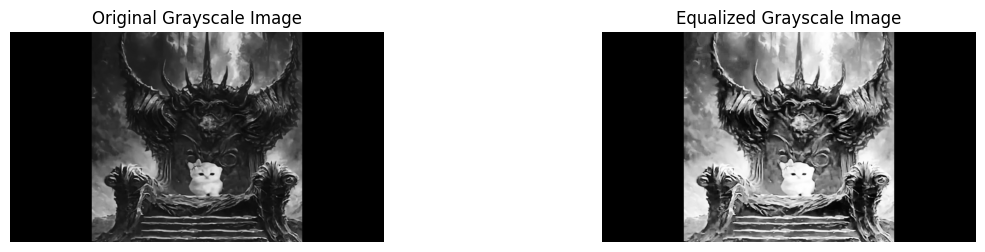

In [4]:
# c, Display the following results:
h_plot = cv2.imread('histo.png')
h_plot_equal = cv2.imread('histo_equalized.png')

cv2.imshow('imgs/maxresdefault.jpg',I_og)
cv2.imshow('hell_cute_cat.jpg',I)

cv2.imshow('resized_cat.jpg', I_resize)
cv2.imshow('histo.png',h_plot)

cv2.imshow('equalized_cat.jpg', I_equalized)
cv2.imshow('histo_equalized.png',h_plot_equal)

# --- Side-by-side comparison ---
plt.figure(figsize=(14, 6))

# Original Grayscale Image
plt.subplot(2, 2, 1)
plt.imshow(I, cmap='gray')
plt.title('Original Grayscale Image')
plt.axis('off')

# Equalized Grayscale Image
plt.subplot(2, 2, 2)
plt.imshow(I_equalized, cmap='gray')
plt.title('Equalized Grayscale Image')
plt.axis('off')

cv2.waitKey(10000)
# cv2.destroyAllWindows()

In [5]:
# d, Print basic infos

import cv2
import numpy as np

I_og = cv2.imread('imgs/hell_cute_cat.jpg')
I_gray = cv2.imread('imgs/hell_cute_cat.jpg', cv2.IMREAD_GRAYSCALE)

def print_image_info(image, label):
    print(f"  {label}")
    print(f"  Image Size     : {image.shape[1]} x {image.shape[0]} (Width x Height)")
    print(f"  Num of Channels: {image.shape[2] if image.ndim == 3 else 1}")
    print(f"  Data Type      : {image.dtype}")
    print(f"  Min Pixel Value: {image.min()}")
    print(f"  Max Pixel Value: {image.max()}")
    print()

print_image_info(I_og,   "Original Color Image")
print_image_info(I_gray, "Grayscale Image")

  Original Color Image
  Image Size     : 1280 x 720 (Width x Height)
  Num of Channels: 3
  Data Type      : uint8
  Min Pixel Value: 0
  Max Pixel Value: 227

  Grayscale Image
  Image Size     : 1280 x 720 (Width x Height)
  Num of Channels: 1
  Data Type      : uint8
  Min Pixel Value: 0
  Max Pixel Value: 227



## Task B2

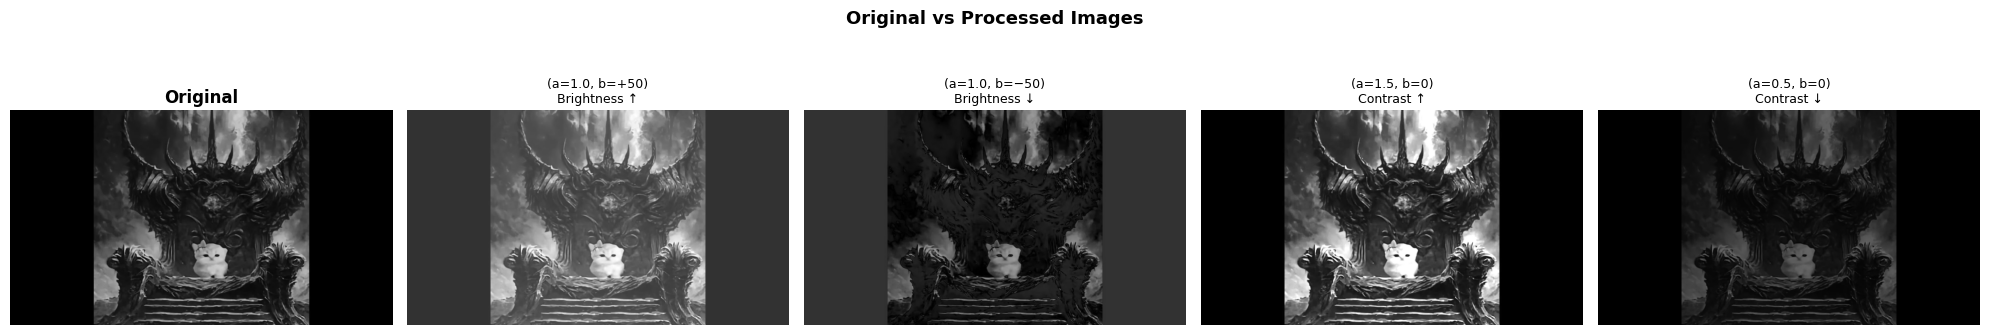

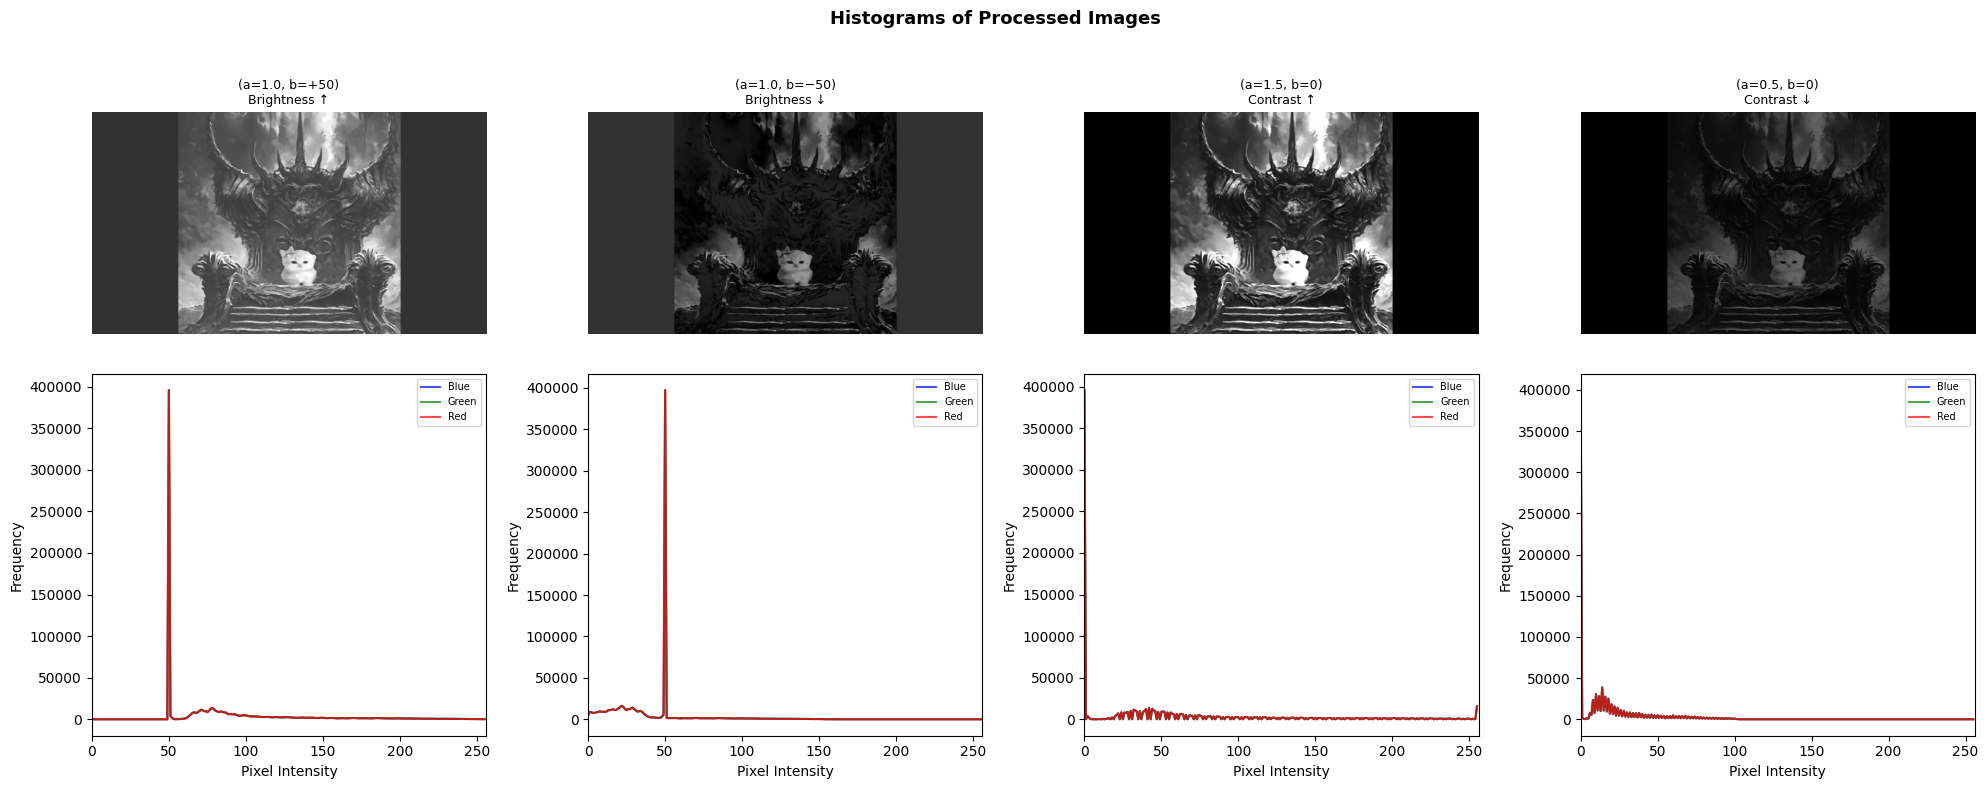

In [10]:
import matplotlib.pyplot as plt
import numpy as np
import cv2

# Load image
img = cv2.imread('imgs/hell_cute_cat.jpg')
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)   

# --- Transformation: img_processed = a * f(x,y) + b ---
# cv2.convertScaleAbs handles clipping to [0,255] automatically
pairs = [(1.0, 50), (1.0, -50), (1.5, 0), (0.5, 0)]
labels = ['(a=1.0, b=+50)\nBrightness ↑',
          '(a=1.0, b=−50)\nBrightness ↓',
          '(a=1.5, b=0)\nContrast ↑',
          '(a=0.5, b=0)\nContrast ↓']

processed_images = []
for (a, b) in pairs:
    result = cv2.convertScaleAbs(img, alpha=a, beta=b)
    processed_images.append(cv2.cvtColor(result, cv2.COLOR_BGR2RGB))

# ── Figure 1: Original + 4 Processed Images ──────────────────────────────────
fig, axes = plt.subplots(1, 5, figsize=(20, 4))

axes[0].imshow(img_rgb)
axes[0].set_title('Original', fontweight='bold')
axes[0].axis('off')

for i, (proc_img, label) in enumerate(zip(processed_images, labels)):
    axes[i+1].imshow(proc_img)
    axes[i+1].set_title(label, fontsize=9)
    axes[i+1].axis('off')

plt.suptitle('Original vs Processed Images', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('comparison_images.png')
plt.show()

# ── Figure 2: Histograms of each processed image ─────────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(20, 8))
colors = ['blue', 'green', 'red']
channel_names = ['Blue', 'Green', 'Red']

for col, (proc_img, label, (a, b)) in enumerate(zip(processed_images, labels, pairs)):
    proc_bgr = cv2.cvtColor(proc_img, cv2.COLOR_RGB2BGR)

    # Top row: processed image thumbnail
    axes[0][col].imshow(proc_img)
    axes[0][col].set_title(label, fontsize=9)
    axes[0][col].axis('off')

    # Bottom row: histogram per channel
    for ch, (color, ch_name) in enumerate(zip(colors, channel_names)):
        hist = cv2.calcHist([proc_bgr], [ch], None, [256], [0, 256])
        axes[1][col].plot(hist, color=color, alpha=0.7, label=ch_name)
    axes[1][col].set_xlim([0, 256])
    axes[1][col].set_xlabel('Pixel Intensity')
    axes[1][col].set_ylabel('Frequency')
    axes[1][col].legend(fontsize=7)

plt.suptitle('Histograms of Processed Images', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('comparison_histograms.png')
plt.show()

## Task B3

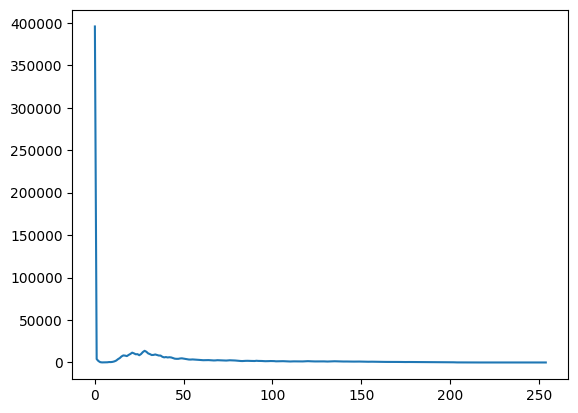

In [6]:
import cv2 
import matplotlib.pyplot as plt

img = cv2.imread('hell_cute_cat.jpg')
hist = cv2.calcHist([img], [0],None, [255],[0,255])

plt.plot(hist)

ret,thresh = cv2.threshold(img, 120, 255, cv2.THRESH_BINARY)
cv2.imshow("Binary Threshold",thresh)

cv2.waitKey(0)
cv2.destroyAllWindows()